# Part 2 — Hierarchical Clustering

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X    = StandardScaler().fit_transform(X)

linkage_methods = ['single', 'complete', 'average', 'ward']
cut_heights     = {'single': 1.5, 'complete': 6.0, 'average': 3.5, 'ward': 10.0}
lcolors         = ['#e74c3c','#3498db','#2ecc71','#9b59b6']
ccolors         = ['#e74c3c','#3498db','#2ecc71','#f39c12']

linkage_matrices = {m: linkage(X, method=m) for m in linkage_methods}


## Dendrograms — 4 Linkage Methods

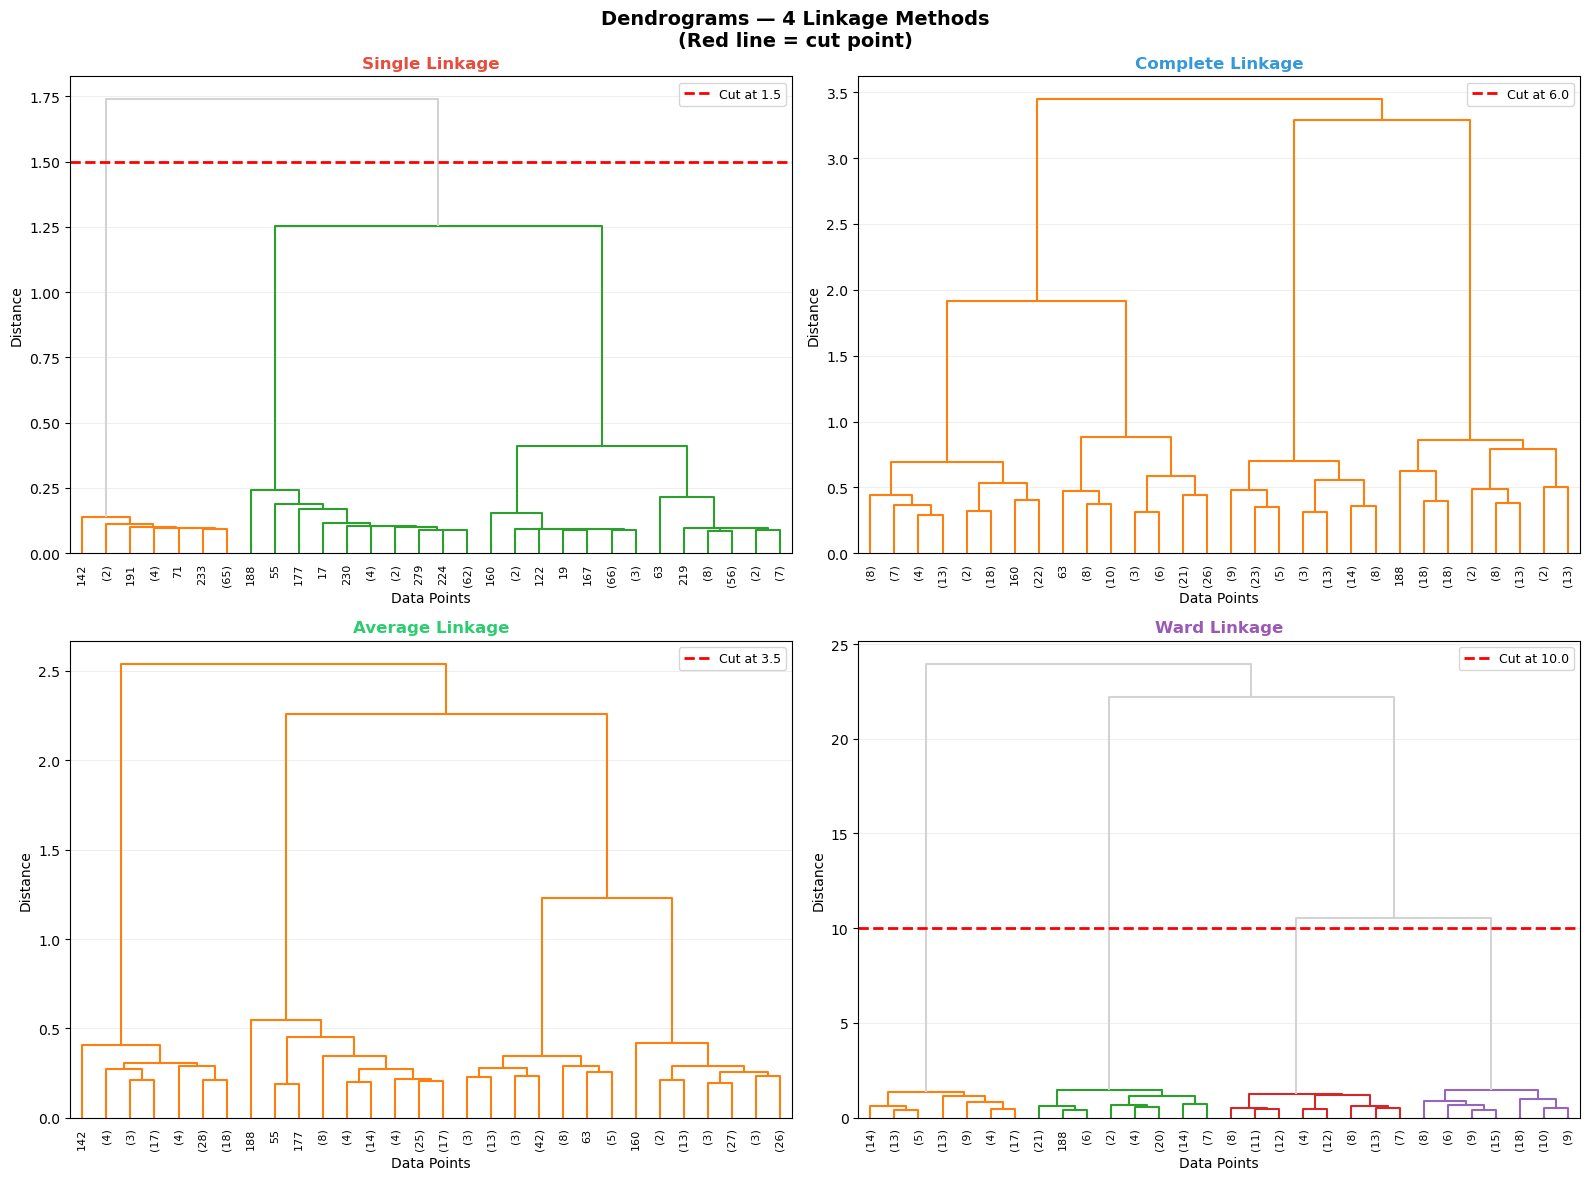

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (method, lc) in enumerate(zip(linkage_methods, lcolors)):
    dendrogram(
        linkage_matrices[method], ax=axes[i],
        truncate_mode='lastp', p=30,
        show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8,
        color_threshold=cut_heights[method],
        above_threshold_color='lightgray'
    )
    axes[i].axhline(y=cut_heights[method], color='red', linestyle='--', linewidth=2,
                    label=f'Cut at {cut_heights[method]}')
    axes[i].set_title(f'{method.capitalize()} Linkage', fontsize=12, fontweight='bold', color=lc)
    axes[i].set_xlabel('Data Points'); axes[i].set_ylabel('Distance')
    axes[i].legend(fontsize=9); axes[i].grid(axis='y', alpha=0.2)

plt.suptitle('Dendrograms — 4 Linkage Methods\n(Red line = cut point)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## Cluster Visualization — All Linkage Methods

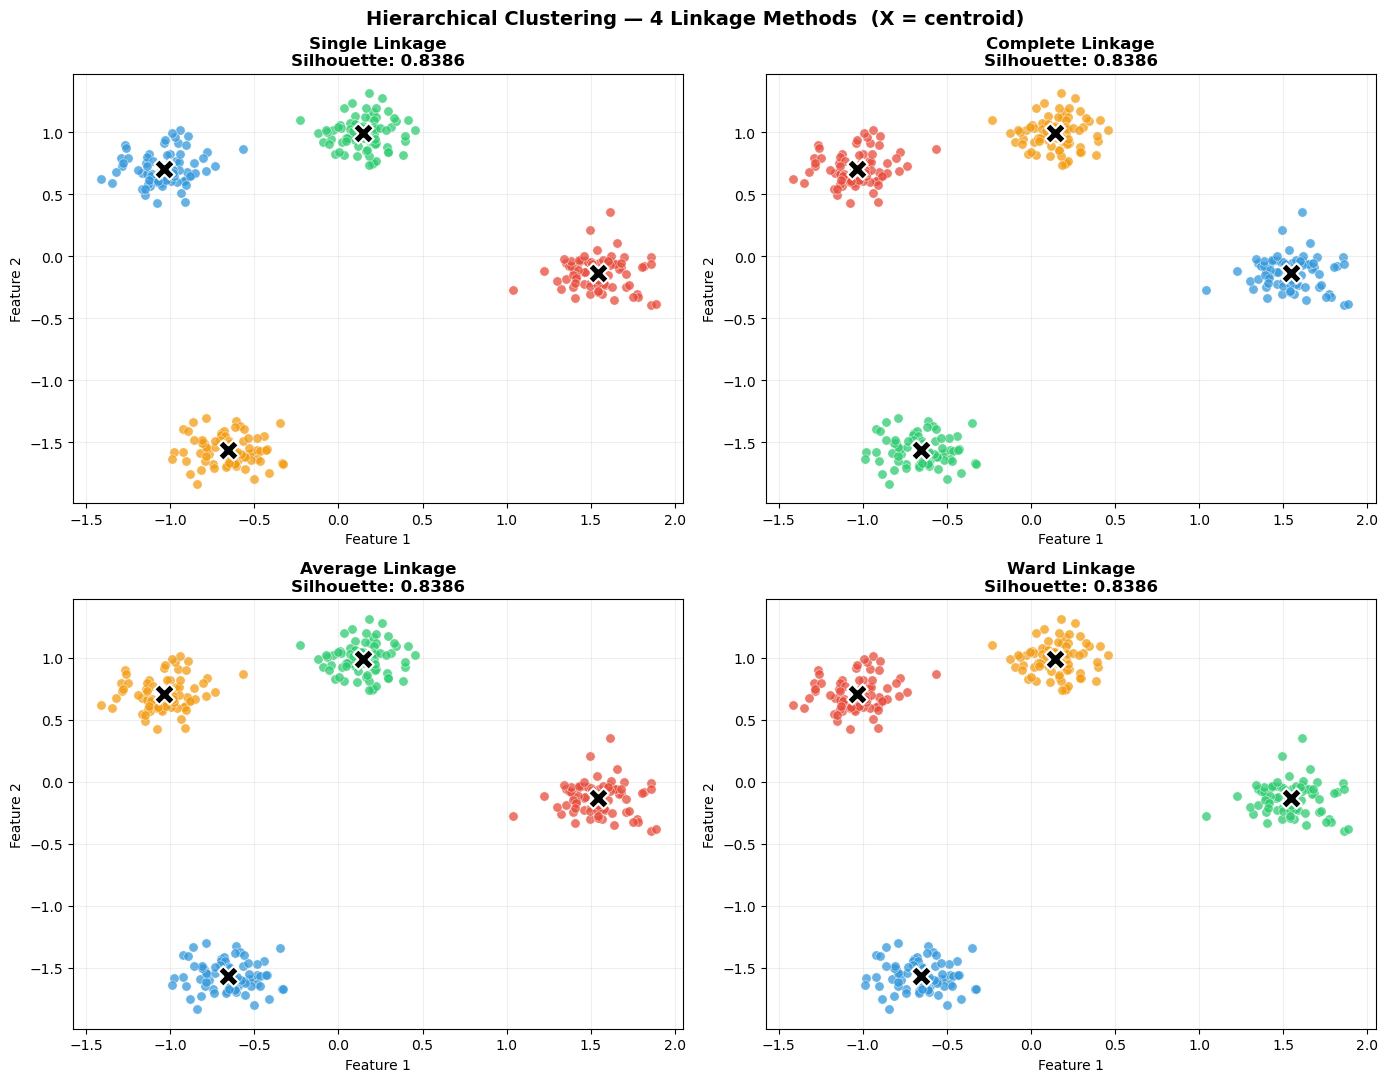

In [5]:
cluster_labels = {}
silhouette_scores = {}

for method in linkage_methods:
    lbl = AgglomerativeClustering(n_clusters=4, linkage=method).fit_predict(X)
    cluster_labels[method]    = lbl
    silhouette_scores[method] = silhouette_score(X, lbl)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, method in enumerate(linkage_methods):
    labels = cluster_labels[method]
    for cid in range(4):
        mask = labels == cid
        axes[i].scatter(X[mask,0], X[mask,1], c=ccolors[cid], s=45, alpha=0.75,
                        edgecolors='white', linewidths=0.4, label=f'Cluster {cid}')
        if mask.sum() > 0:
            cx = X[mask].mean(axis=0)
            axes[i].scatter(cx[0], cx[1], c='black', s=220, marker='X', zorder=5,
                            edgecolors='white', linewidths=1.5)
    axes[i].set_title(f'{method.capitalize()} Linkage\nSilhouette: {silhouette_scores[method]:.4f}',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Feature 1'); axes[i].set_ylabel('Feature 2')
    axes[i].grid(True, alpha=0.2)

plt.suptitle('Hierarchical Clustering — 4 Linkage Methods  (X = centroid)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## Silhouette Comparison — All Methods

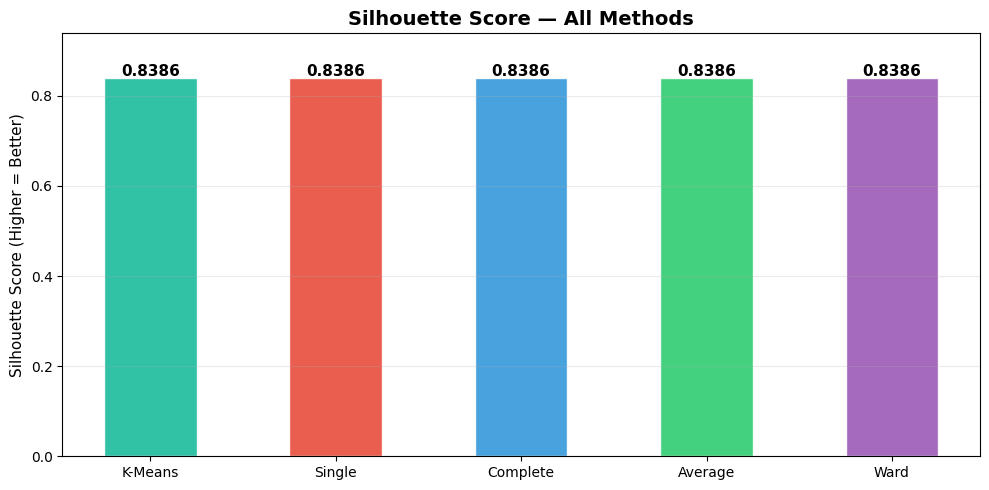

In [4]:
km_lbl   = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42).fit_predict(X)
sil_km   = silhouette_score(X, km_lbl)

all_names  = ['K-Means'] + [m.capitalize() for m in linkage_methods]
all_scores = [sil_km]    + [silhouette_scores[m] for m in linkage_methods]
bar_cols   = ['#1abc9c','#e74c3c','#3498db','#2ecc71','#9b59b6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(all_names, all_scores, color=bar_cols, edgecolor='white', alpha=0.9, width=0.5)
for bar, score in zip(bars, all_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Silhouette Score — All Methods', fontsize=14, fontweight='bold')
ax.set_ylabel('Silhouette Score (Higher = Better)', fontsize=11)
ax.set_ylim(0, max(all_scores)+0.1)
ax.grid(axis='y', alpha=0.25); plt.tight_layout(); plt.show()


## Final Comparison Table

In [5]:
print('=' * 52)
print('     SILHOUETTE SCORE COMPARISON TABLE')
print('=' * 52)
print(f'{"Algorithm":<22} {"Silhouette":>14} {"Rank":>8}')
print('-' * 52)
ranked = sorted(zip(all_names, all_scores), key=lambda x: x[1], reverse=True)
for rank, (name, score) in enumerate(ranked, 1):
    flag = '  <-- BEST' if rank == 1 else ''
    print(f'{name:<22} {score:>14.4f} {rank:>8}{flag}')
print('=' * 52)
print()
print('Observation:')
print('  Single   -> Chaining effect, elongated clusters')
print('  Complete -> Compact clusters, outlier sensitive')
print('  Average  -> Balanced, generally reliable')
print('  Ward     -> Minimizes inertia, usually best result')


     SILHOUETTE SCORE COMPARISON TABLE
Algorithm                  Silhouette     Rank
----------------------------------------------------
K-Means                        0.8386        1  <-- BEST
Single                         0.8386        2
Complete                       0.8386        3
Average                        0.8386        4
Ward                           0.8386        5

Observation:
  Single   -> Chaining effect, elongated clusters
  Complete -> Compact clusters, outlier sensitive
  Average  -> Balanced, generally reliable
  Ward     -> Minimizes inertia, usually best result
